# 劳动力回流

参照国家统计局标准以及贾男和马俊龙（2015）的做法，本文根据个人的户口所在地与常住地的差异、就业状态、户籍类型以及年龄等特征定义劳动力流动。具体来说，本文将年龄在16～70岁、具有农业户籍、有工作但常住地与户籍所在乡镇不一致的个体定义为劳动力流动个体。这样定义，有以下几个层面的考虑。首先，从年龄来看，16～70岁这一区间的选择具备合理性。一方面，从16岁的标准来看，根据《中华人民共和国劳动法》，个体满16周岁即可被用人单位雇佣；另一方面，从70岁的标准来看，农村居民通常并无严格的退休年龄标准，只要有比较合适的就业机会，即便年满60周岁，他们仍然会选择继续工作。而且，与城镇居民相比，农村居民收入偏低，通常需要持续赚取收入来维持家庭生计和未来养老消费。因而，本文将70岁作为劳动力流动个体的年龄上限。其次，国家统计局对外出务工者就业状态的界定标准是在外从业，即有工作的个体。最后，从户口所在地与常住地的差异来看，国家统计局对劳动力的“外出”给出了明确的地理界定，将外出农民工界定为在户籍所在乡镇地域以外从业者，将本地农民工界定为在户籍所在乡镇地域以内从业者。基于上述分析，如果家庭中有劳动力流动个体，则将家庭劳动力流动变量赋值为1，否则为0。此外，本文还分别定义了劳动力流动人数和比例变量。

中国家庭金融调查共有2011年、2013年、2015年、2017年、2019年五轮数据，其中只有2017年和2019年两轮数据详细询问了个体的回流决策，因此本文主要利用这两轮数据进行研究。农村回流劳动力需满足农村户籍、曾经外出务工并在接受调查时已经回到户籍地两个特征，因此，本文依据以下条件对样本进行筛选：第一，保留样本中农村户籍且年龄在16-70岁的劳动力年龄人口；第二，根据问卷中“是否有过离开本市，去其他地方工作的经历？”问题，定义是否曾有外出务工经历，同时，将曾在户籍地所在市以外居住或工作过半年及以上且返回到户籍地的群体定义为回流群体；第三，参考张吉鹏等（2020），为避免户籍迁移人口的干扰，删除了曾有过跨市户口迁移经历的样本。根据以上三个条件定义处于回流状态的农民工为回流劳动力，$return_{it} = 1$；而仍处于外出务工状态的农民工则为非回流劳动力，$return_{it}=0$。


进一步地，根据问题“哪一年去到（流动地）所在地？”“是哪一年回到户籍所在地？”识别出个体外出务工与回流的年份。然后根据个体外出务工时间和回流时间构造2012-2017非平衡面板数据。假设个体$t$从$t_0(t_0\geq2012)$年开始外出务工，在$t_0+n(t_0+n\geq2017)$年回流。则个体“是否回流”的虚拟变量为：<br>
$$
    return_{it} = 
\begin{cases} 
0, & t_{0} \leq t < t_{0} + n \\
1, & t = t_{0} + n
\end{cases}
$$


劳动力回流

In [1]:
import pandas as pd
import os
os.chdir("C:\\Users\\gao_l\\Documents\\data\\CHFS")
family_2019 = pd.read_stata("2019\\CHFSdata-2019\\2019stata14\\chfs2019_hh_202112.dta")
person_2019 = pd.read_stata("2019\\CHFSdata-2019\\2019stata14\\chfs2019_ind_202112.dta")
master_2019 = pd.read_stata("2019\\CHFSdata-2019\\2019stata14\\chfs2019_master_202112.dta")

In [2]:
family_2017 = pd.read_stata("2017\\CHFSdata-2017\\2017stata14\\hh2017_20191120_version14.dta")
person_2017 = pd.read_stata("2017\\CHFSdata-2017\\2017stata14\\ind2017_20191202_version14.dta")
master_2017 = pd.read_stata("2017\\CHFSdata-2017\\2017stata14\\chfs2017_master_city_20191120_version14.dta")

In [3]:
citycode = pd.read_excel("citycode.xlsx")

In [4]:
print(person_2017)

              hhid   hhid_2017  hhid_2011   hhid_2013   hhid_2015  \
0       2017000001  2017000001                                      
1       2017000001  2017000001                                      
2       2013013417  2017000002             2013013417  2015018254   
3       2013013417  2017000002             2013013417  2015018254   
4       2013013417  2017000002             2013013417  2015018254   
...            ...         ...        ...         ...         ...   
127007   201100379  2017040010  201100379  2013000784  2015000767   
127008   201100379  2017040010  201100379  2013000784  2015000767   
127009  2017040011  2017040011                                      
127010  2017040011  2017040011                                      
127011  2017040011  2017040011                                      

           hhcid_2017  pline_raw  pline  hhead  track  ...  f6204_imp  \
0       com2017000668          1      1    NaN      0  ...        NaN   
1       com2017000668    

In [5]:
! pip install geopandas

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     -------------------------------------- 323.6/323.6 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 16.2/16.2 MB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 1.4/1.4 MB 5.4 MB/s eta 0:00:00
     ---------------------------------------- 6.2/6.2 MB 4.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
print(family_2019)

             hhid  a1001  a1002  a1003  a1003a  a1007  a1008  a1009  a1013a  \
0       201107290    1.0    1.0    1.0     1.0    1.0    1.0    3.0     1.0   
1       201108299    1.0    1.0    1.0     1.0    1.0    1.0    3.0     1.0   
2       201108301    1.0    1.0    1.0     2.0    1.0    1.0    3.0     1.0   
3       201108302    1.0    1.0    1.0     1.0    1.0    1.0    3.0     1.0   
4       201108303    1.0    1.0    1.0     2.0    1.0    1.0    3.0     1.0   
...           ...    ...    ...    ...     ...    ...    ...    ...     ...   
34638  2019034639    1.0    1.0    1.0     1.0    1.0    1.0    3.0     1.0   
34639  2019034640    1.0    1.0    3.0     2.0    1.0    1.0    3.0     1.0   
34640  2019034641    1.0    1.0    1.0     2.0    1.0    1.0    3.0     1.0   
34641  2019034642    1.0    1.0    1.0     2.0    1.0    1.0    3.0     1.0   
34642  2019034643    1.0    1.0    1.0     2.0    1.0    1.0    3.0     1.0   

       a1100  ...  k2208 k2208_imp  k2208_imp_dummy

In [19]:
print(person_2019)

              hhid  pline  pline_order  hhead  a1106  a1106c  a1106d  a1108  \
0        201107290      1            1      1    NaN     NaN     NaN    NaN   
1        201108299      2            2      0    NaN     NaN     NaN    NaN   
2        201108299      1            1      1    NaN     NaN     NaN    NaN   
3        201108301      3            3      0    NaN     NaN     NaN    NaN   
4        201108301      5            5      0    NaN     NaN     NaN    NaN   
...            ...    ...          ...    ...    ...     ...     ...    ...   
107003  2019034642      4            4      0    NaN     NaN     NaN    NaN   
107004  2019034643      2            2      1    NaN     NaN     NaN    NaN   
107005  2019034643      4            4      0    NaN     NaN     NaN    NaN   
107006  2019034643      3            3      0    NaN     NaN     NaN    NaN   
107007  2019034643      1            1      0    NaN     NaN     NaN    NaN   

        a1113  a1114  ...  h3003a_3_mc  h3003a_4_mc

| 变量             | 2019     |
| ---------------- | -------- |
| 现住地           | a2016b   |
| 户籍地           | a2019    |
| 户口类型         | a2022    |
| 是农转非农户口   | a2022a   |
| 转为非农户口的时间 | a2022b   |
| 是否外地生活或工作 | a2023g   |
| 去哪个省份       | a2023j   |
| 哪一年去外地     | a2023k   |
| 哪一年回来       | a2023i   |
| 返乡原因         | a2023ia  |
| 外出务工工作性质 | a20231b  |
| 工作实际收入     | a20231c  |
| 最近一次跨区/县户口时的户口迁出地| a2022m|

### 2019年回流数据

In [4]:
# 户籍
huji = person_2019["a2019_prov"]
print(huji.unique())

# 是否是农村户口
person_2019["rural"] = 0
person_2019.loc[person_2019['a2022'] == 1, 'rural'] = 1
person_2019.loc[person_2019['a2022'] != 1, 'rural'] = 0

# 年龄
print(person_2019[person_2019["a2005"].isnull()])
person_2019["age"] = 2019 - person_2019["a2005"]

# 是否曾有外出务工经历
# 初始化labor_migra
person_2019['labor_migra'] = 0
# .loc[]: 这是Pandas DataFrame的一个索引器，用于基于标签选择数据。在这里，它用于选择满足条件的行。
person_2019.loc[person_2019['a2023g'] == 1, 'labor_migra'] = 1
person_2019.loc[person_2019['a2023g'] != 1, 'labor_migra'] = 0

# 将曾在户籍地所在市以外居住或工作过半年及以上且返回到户籍地的群体定义为回流群体。（2019年已经回流的群体）
person_2019['back'] = 0
person_2019.loc[(person_2019['a2023g'] == 1) & (person_2019['a2023i'] <= 2019) & person_2019['a2023i'].notna(), 'back'] = 1
person_2019.loc[person_2019['back'] != 1 , 'back'] = 0

['广西壮族自治区' '甘肃省' '北京市' '河北省' '黑龙江省' '湖北省' '广东省' '四川省' '浙江省' '河南省' '山西省'
 '陕西省' '山东省' '天津市' '内蒙古自治区' '安徽省' '江苏省' '重庆市' '上海市' '福建省' '' '云南省' '辽宁省'
 '吉林省' '新疆维吾尔自治区' '湖南省' '江西省' '海南省' '西藏自治区' '贵州省' '青海省' '宁夏回族自治区' '中国香港'
 '中国台湾' '香港' '澳门']
              hhid  pline  pline_order  hhead  a1106  a1106c  a1106d  a1108  \
43168   2017008144      1            1      1    1.0     NaN     2.0    1.0   
43169   2017008144      2            2      0    1.0     NaN     1.0    1.0   
59777   2019003417      3            3      0    NaN     NaN     NaN    NaN   
68612   2019011079      2            2      1    NaN     NaN     NaN    NaN   
68613   2019011079      4            4      0    NaN     NaN     NaN    NaN   
68614   2019011079      1            1      0    NaN     NaN     NaN    NaN   
68615   2019011079      3            3      0    NaN     NaN     NaN    NaN   
71926   2019013409      1            1      0    NaN     NaN     NaN    NaN   
71927   2019013409      3            3      1    NaN

C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4150337318.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2019["rural"] = 0
C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4150337318.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2019["age"] = 2019 - person_2019["a2005"]
C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4150337318.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

In [5]:
# 筛选样本
# 保留样本中年龄在16-70岁的劳动力人口
person_2019_f = person_2019[(person_2019["age"]>16) & (person_2019["age"]<70)]
# 为避免户籍迁移人口的干扰，删除了曾经有过跨市户口迁移经历的样本
person_2019_f = person_2019_f[(person_2019_f['a2022m_prov'].notnull()) & (person_2019_f['a2019_prov'] != person_2019_f['a2022m_prov'])]

### 回流数据和省份数据连接

In [6]:
backdata2019 = person_2019[['hhid', 'pline', 'back']]
print(backdata2019)

              hhid  pline  back
0        201107290      1     0
1        201108299      2     0
2        201108299      1     0
3        201108301      3     0
4        201108301      5     0
...            ...    ...   ...
107003  2019034642      4     0
107004  2019034643      2     0
107005  2019034643      4     0
107006  2019034643      3     0
107007  2019034643      1     0

[107008 rows x 3 columns]


In [7]:
print(master_2019)

              hhid  pline          hhcid  track  rural pa28 pab pabcd  \
0       2019000001      1  hhcid20170423      0      0                  
1       2019000002      4  hhcid20170423      0      0        A         
2       2019000002      3  hhcid20170423      0      0        A         
3       2019000002      2  hhcid20170423      0      0        A         
4       2019000002      1  hhcid20170423      0      0        A         
...            ...    ...            ...    ...    ...  ...  ..   ...   
107003  2019034642      4  hhcid20131048      0      0   15   B         
107004  2019034643      4  hhcid20131048      0      0        A    A1   
107005  2019034643      1  hhcid20131048      0      0        A    A1   
107006  2019034643      3  hhcid20131048      0      0        A    A1   
107007  2019034643      2  hhcid20131048      0      0        A    A1   

          weight_hh   weight_ind  ... agri_debt busi_debt house_debt  \
0        800.748047   616.559753  ...       NaN    

In [8]:
backdata2019 = person_2019[['hhid', 'pline', 'back']]
merged_data = pd.merge(master_2019, backdata2019, on=['hhid', 'pline'], how='inner')

In [10]:
print(merged_data)

              hhid  pline          hhcid  track  rural pa28 pab pabcd  \
0       2019000001      1  hhcid20170423      0      0                  
1       2019000002      4  hhcid20170423      0      0        A         
2       2019000002      3  hhcid20170423      0      0        A         
3       2019000002      2  hhcid20170423      0      0        A         
4       2019000002      1  hhcid20170423      0      0        A         
...            ...    ...            ...    ...    ...  ...  ..   ...   
107003  2019034642      4  hhcid20131048      0      0   15   B         
107004  2019034643      4  hhcid20131048      0      0        A    A1   
107005  2019034643      1  hhcid20131048      0      0        A    A1   
107006  2019034643      3  hhcid20131048      0      0        A    A1   
107007  2019034643      2  hhcid20131048      0      0        A    A1   

          weight_hh   weight_ind  ... busi_debt house_debt comprop_debt  \
0        800.748047   616.559753  ...       NaN 

### 2019年不同省份外出务工的劳动力回流群体数量

In [9]:
returnee_counts2019 = pd.DataFrame(merged_data.groupby('prov', as_index = False)['back'].sum()) 
returnee_counts2019.rename(columns={'prov': 'prov_CHN'}, inplace=True)
returnee_counts2019["year"] = 2019

In [16]:
print(returnee_counts2019)

   prov_CHN  back  year
0       上海市   310  2019
1       云南省   490  2019
2    内蒙古自治区   249  2019
3       北京市   223  2019
4       吉林省   162  2019
5       四川省   692  2019
6       天津市   250  2019
7   宁夏回族自治区    94  2019
8       安徽省   567  2019
9       山东省   203  2019
10      山西省   272  2019
11      广东省   731  2019
12  广西壮族自治区   481  2019
13      江苏省   358  2019
14      江西省   450  2019
15      河北省   372  2019
16      河南省   458  2019
17      浙江省   584  2019
18      海南省   378  2019
19      湖北省   568  2019
20      湖南省   713  2019
21      甘肃省   255  2019
22      福建省   344  2019
23      贵州省   432  2019
24      辽宁省   289  2019
25      重庆市   465  2019
26      陕西省   372  2019
27      青海省   205  2019
28     黑龙江省   345  2019


### 2017年回流数据

In [108]:
print(person_2017)

              hhid   hhid_2017 hhid_2011   hhid_2013   hhid_2015  \
0       2017000001  2017000001                                     
1       2017000001  2017000001                                     
2       2013020230  2017000005            2013020230  2015027944   
3       2013020230  2017000005            2013020230  2015027944   
4       2013020230  2017000005            2013020230  2015027944   
...            ...         ...       ...         ...         ...   
126610  2015030052  2017030301                        2015030052   
126611  2017030936  2017030936                                     
126612  2015000846  2017031831                        2015000846   
126613  2015000846  2017031831                        2015000846   
126614  2013022114  2017034133            2013022114  2015030234   

           hhcid_2017  pline_raw  pline  hhead  track  ...  rural   age  \
0       com2017000668          1      1    NaN      0  ...      1  45.0   
1       com2017000668          2 

In [17]:
print(person_2017)

              hhid   hhid_2017  hhid_2011   hhid_2013   hhid_2015  \
0       2017000001  2017000001                                      
1       2017000001  2017000001                                      
2       2013013417  2017000002             2013013417  2015018254   
3       2013013417  2017000002             2013013417  2015018254   
4       2013013417  2017000002             2013013417  2015018254   
...            ...         ...        ...         ...         ...   
127007   201100379  2017040010  201100379  2013000784  2015000767   
127008   201100379  2017040010  201100379  2013000784  2015000767   
127009  2017040011  2017040011                                      
127010  2017040011  2017040011                                      
127011  2017040011  2017040011                                      

           hhcid_2017  pline_raw  pline  hhead  track  ...  f6204_imp  \
0       com2017000668          1      1    NaN      0  ...        NaN   
1       com2017000668    

In [18]:
print(citycode)

    citycode  province
0         11       北京市
1         12       天津市
2         13       河北省
3         14       山西省
4         15    内蒙古自治区
5         21       辽宁省
6         22       吉林省
7         23      黑龙江省
8         31       上海市
9         32       江苏省
10        33       浙江省
11        34       安徽省
12        35       福建省
13        36       江西省
14        37       山东省
15        41       河南省
16        42       湖北省
17        43       湖南省
18        44       广东省
19        45   广西壮族自治区
20        46       海南省
21        50       重庆市
22        51       四川省
23        52       贵州省
24        53       云南省
25        54     西藏自治区
26        61       陕西省
27        62       甘肃省
28        63       青海省
29        64   宁夏回族自治区
30        65  新疆维吾尔自治区
31        71       台湾省
32        81   香港特别行政区
33        82   澳门特别行政区


In [10]:
# 户籍
person_2017["citycode"] = person_2017["a2019"].str[:2]
citycode['citycode'] = citycode['citycode'].astype(str)
person_2017 = pd.merge(person_2017, citycode, on=['citycode'], how='inner')

# 是否是农村户口
person_2017["rural"] = 0
person_2017.loc[person_2017['a2022'] == 1, 'rural'] = 1
person_2017.loc[person_2017['a2022'] != 1, 'rural'] = 0

# 年龄
# print(person_2017[person_2017["a2005"].isnull()])
person_2017["age"] = 2017 - person_2017["a2005"]

# 是否曾有外出务工经历
# 初始化labor_migra
person_2017['labor_migra'] = 0
# .loc[]: 这是Pandas DataFrame的一个索引器，用于基于标签选择数据。在这里，它用于选择满足条件的行。
person_2017.loc[person_2017['a2023g'] == 1, 'labor_migra'] = 1
person_2017.loc[person_2017['a2023g'] != 1, 'labor_migra'] = 0

# 将曾在户籍地所在市以外居住或工作过半年及以上且返回到户籍地的群体定义为回流群体。（2019年已经回流的群体）
person_2017['back'] = 0
person_2017.loc[(person_2017['a2023g'] == 1) & (person_2017['a2023i'] <= 2017) & person_2017['a2023i'].notna(), 'back'] = 1
person_2017.loc[person_2017['back'] != 1 , 'back'] = 0


# 计算2017年劳动力回流数据
backdata2017 = person_2017[['hhid', 'pline', 'back']]
merged_data = pd.merge(master_2017, backdata2017, on=['hhid', 'pline'], how='inner')

C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4044028461.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2017["citycode"] = person_2017["a2019"].str[:2]
C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4044028461.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2017["rural"] = 0
C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4044028461.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

In [62]:
print(master_2017)

              hhid  hhid_2011   hhid_2013   hhid_2015   hhid_2017  pline  \
0        201100002  201100002  2013000302  2015000295  2017016253      2   
1        201100002  201100002  2013000302  2015000295  2017016253      3   
2        201100002  201100002  2013000302  2015000295  2017016253      4   
3        201100006  201100006  2013000305  2015000299  2017017482      1   
4        201100006  201100006  2013000305  2015000299  2017017482      2   
...            ...        ...         ...         ...         ...    ...   
127007  2017040009                                     2017040009      1   
127008  2017040009                                     2017040009      2   
127009  2017040011                                     2017040011      1   
127010  2017040011                                     2017040011      2   
127011  2017040011                                     2017040011      3   

        city_lab  county_lab pab prov_CHN  province  qc  rural        swgt_h  \
0      

In [21]:
print(master_2017)

              hhid  hhid_2011   hhid_2013   hhid_2015   hhid_2017  pline  \
0        201100002  201100002  2013000302  2015000295  2017016253      2   
1        201100002  201100002  2013000302  2015000295  2017016253      3   
2        201100002  201100002  2013000302  2015000295  2017016253      4   
3        201100006  201100006  2013000305  2015000299  2017017482      1   
4        201100006  201100006  2013000305  2015000299  2017017482      2   
...            ...        ...         ...         ...         ...    ...   
127007  2017040009                                     2017040009      1   
127008  2017040009                                     2017040009      2   
127009  2017040011                                     2017040011      1   
127010  2017040011                                     2017040011      2   
127011  2017040011                                     2017040011      3   

        city_lab  county_lab pab prov_CHN  province  qc  rural        swgt_h  \
0      

In [11]:
returnee_counts2017 = pd.DataFrame(merged_data.groupby('prov_CHN', as_index=False)['back'].sum()) 
returnee_counts2017["year"] = 2017

In [103]:
print(returnee_counts2017)

   prov_CHN  back  year
0       上海市   585  2017
1       云南省   423  2017
2    内蒙古自治区   199  2017
3       北京市   455  2017
4       吉林省   422  2017
5       四川省   688  2017
6       天津市   396  2017
7   宁夏回族自治区   166  2017
8       安徽省   512  2017
9       山东省   595  2017
10      山西省   520  2017
11      广东省  1338  2017
12  广西壮族自治区   449  2017
13      江苏省   734  2017
14      江西省   437  2017
15      河北省   625  2017
16      河南省   461  2017
17      浙江省   841  2017
18      海南省   407  2017
19      湖北省   696  2017
20      湖南省   823  2017
21      甘肃省   389  2017
22      福建省   605  2017
23      贵州省   330  2017
24      辽宁省   758  2017
25      重庆市   636  2017
26      陕西省   586  2017
27      青海省   261  2017
28     黑龙江省   393  2017


### 2015年回流数据

In [12]:
master_2015 = pd.read_stata("2015\\CHFSdata-2015\\2015stata14\\chfs2015_master_202203.dta")

In [60]:
print(master_2015)

             hhid          hhcid prov_CHN province  rural         swgt  \
0       201100002  hhcid20110001      北京市  beijing    0.0  6623.868164   
1       201100006  hhcid20110001      北京市  beijing    0.0  6623.868164   
2       201100007  hhcid20110001      北京市  beijing    0.0  6623.868164   
3       201100008  hhcid20110001      北京市  beijing    0.0  6623.868164   
4       201100012  hhcid20110001      北京市  beijing    0.0  6623.868164   
...           ...            ...      ...      ...    ...          ...   
37284  2015037258  hhcid20131045  宁夏回族自治区  ningxia    0.0  6604.346680   
37285  2015037259  hhcid20131045  宁夏回族自治区  ningxia    0.0  6604.346680   
37286  2015037271  hhcid20131045  宁夏回族自治区  ningxia    0.0  6604.346680   
37287  2015037282  hhcid20131046  宁夏回族自治区  ningxia    1.0  3473.334961   
37288  2015037301  hhcid20131047  宁夏回族自治区  ningxia    1.0  3192.309814   

       region aorb  city_lab  
0         1.0    a      10.0  
1         1.0    b      10.0  
2         1.0    a

In [13]:
# 将曾在户籍地所在市以外居住或工作过半年及以上且返回到户籍地的群体定义为回流群体。（2017年记录了2015年已经回流的群体）
person_2017['back2015'] = 0
person_2017.loc[(person_2017['a2023g'] == 1) & (person_2017['a2023i'] <= 2015) & person_2017['a2023i'].notna(), 'back2015'] = 1
person_2017.loc[person_2017['back2015'] != 1 , 'back2015'] = 0
backdata2015 = person_2017[["hhid", "pline", "back2015"]]

# 2015年的省份数据拼接
merged_data = pd.merge(master_2015, backdata2015, on=['hhid'], how='inner')
returnee_counts2015 = pd.DataFrame(merged_data.groupby('prov_CHN', as_index=False)['back2015'].sum().rename(columns={'back2015': 'back'})) 

returnee_counts2015["year"] = 2015
returnee_counts2015.rename(columns={'back2015': 'back'}, inplace=True)


C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\31985977.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2017['back2015'] = 0


In [28]:
print(returnee_counts2015)

   prov_CHN  back  year
0       上海市   283  2015
1       云南省   193  2015
2    内蒙古自治区   125  2015
3       北京市   259  2015
4       吉林省   224  2015
5       四川省   383  2015
6       天津市   230  2015
7   宁夏回族自治区    98  2015
8       安徽省   252  2015
9       山东省   368  2015
10      山西省   279  2015
11      广东省   685  2015
12  广西壮族自治区   245  2015
13      江苏省   401  2015
14      江西省   262  2015
15      河北省   355  2015
16      河南省   209  2015
17      浙江省   458  2015
18      海南省   190  2015
19      湖北省   389  2015
20      湖南省   435  2015
21      甘肃省   225  2015
22      福建省   316  2015
23      贵州省   178  2015
24      辽宁省   372  2015
25      重庆市   374  2015
26      陕西省   276  2015
27      青海省   107  2015
28     黑龙江省   181  2015


### 2013年回流数据

In [14]:
master_2013 = pd.read_stata("2013\\CHFSdata-2013\\2013stata14\\chfs2013_master_city_20180504_version14.dta")

In [15]:
# 将曾在户籍地所在市以外居住或工作过半年及以上且返回到户籍地的群体定义为回流群体。（2017年记录了2013年已经回流的群体）
person_2017['back2013'] = 0
person_2017.loc[(person_2017['a2023g'] == 1) & (person_2017['a2023i'] <= 2013) & person_2017['a2023i'].notna(), 'back2013'] = 1
person_2017.loc[person_2017['back2013'] != 1 , 'back2013'] = 0
backdata2013 = person_2017[["hhid", "pline", "back2013"]]

# 2013年的省份数据拼接
merged_data = pd.merge(master_2013, backdata2013, on=['hhid'], how='inner')
returnee_counts2013 = pd.DataFrame(merged_data.groupby('prov_CHN', as_index=False)['back2013'].sum().rename(columns={'back2013': 'back'})) 
returnee_counts2013["year"] = 2013
# returnee_counts2013.rename(columns={'back2013': 'back'}, inplace=True)
print(returnee_counts2013)

   prov_CHN  back  year
0       上海市   184  2013
1       云南省   115  2013
2    内蒙古自治区    92  2013
3       北京市   158  2013
4       吉林省    97  2013
5       四川省   190  2013
6       天津市   162  2013
7   宁夏回族自治区    61  2013
8       安徽省   130  2013
9       山东省   142  2013
10      山西省   155  2013
11      广东省   241  2013
12  广西壮族自治区   168  2013
13      江苏省   204  2013
14      江西省   204  2013
15      河北省   130  2013
16      河南省   163  2013
17      浙江省   235  2013
18      海南省    95  2013
19      湖北省   270  2013
20      湖南省   211  2013
21      甘肃省   170  2013
22      福建省   148  2013
23      贵州省   120  2013
24      辽宁省   146  2013
25      重庆市   175  2013
26      陕西省   144  2013
27      青海省    71  2013
28     黑龙江省   109  2013


C:\Users\gao_l\AppData\Local\Temp\ipykernel_2284\4201285312.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  person_2017['back2013'] = 0


In [16]:
df_combined = pd.concat([returnee_counts2013, returnee_counts2015, returnee_counts2017, returnee_counts2019], ignore_index=True)
print(df_combined)

    prov_CHN  back  year
0        上海市   184  2013
1        云南省   115  2013
2     内蒙古自治区    92  2013
3        北京市   158  2013
4        吉林省    97  2013
..       ...   ...   ...
111      辽宁省   289  2019
112      重庆市   465  2019
113      陕西省   372  2019
114      青海省   205  2019
115     黑龙江省   345  2019

[116 rows x 3 columns]


### 使用pyecharts绘制各省数量图

In [18]:
! pip install pyecharts

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     -------------------------------------- 151.0/151.0 kB 1.8 MB/s eta 0:00:00
     ---------------------------------------- 75.6/75.6 kB 1.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 地图可视化

In [ ]:
from pyecharts.charts import Map
from pyecharts import options as opts

# 创建地图实例
map_chart = Map()

# 添加数据到地图，数据格式是[(地区名, 值), ...]
map_chart.add(
    "劳动力流动数量",
    list(returnee_counts2019[['prov_CHN', 'back']].values),  # 添加省份及其人口数据
    "china"  # 使用中国地图
)

# 设置全局配置（标题等）
map_chart.set_global_opts(
    title_opts=opts.TitleOpts(title="中国各省劳动力流动分布"),
    visualmap_opts=opts.VisualMapOpts(
        min_= 50,  # 设置最小值
        max_= 1500,  # 设置最大值
        is_piecewise=True,  # 设置分段
        pieces=[
            {"min": 1000, "color": "#FF0000"},
            {"min": 500, "max": 999, "color": "#FF4500"},
            {"min": 202, "max": 499, "color": "#FF6347"},
            {"min": 71, "max": 201, "color": "#FFD700"},
            {"max": 70, "color": "#90EE90"}
        ]
    )
)

# 渲染为HTML文件
map_chart.render("C:\\Users\\gao_l\\Desktop\\python\\11.dataanalyze2\\china_population_map.html")

'C:\\Users\\gao_l\\Desktop\\python\\11.dataanalyze2\\china_population_map.html'

In [ ]:
print(returnee_counts2019)

### 箱型图

箱型图（Boxplot），也称为箱线图或盒须图，是一种用于展示一组数据分布特征的统计图表。它能够提供数据的最小值、第一四分位数（Q1）、中位数（Q2）、第三四分位数（Q3）和最大值的直观展示，并且可以用来识别数据中的异常值

超大型城市=1；特大城市=2；大城市=3；中小型城市=4
根据《国务院关于调整城市规模划分标准的通知》，认定 1000 万以上常住人口的城市为超大城市，500
万～1000 万为特大城市，100 万～500 万为大城市，50 万～100 万为中等城市，50 万以下为小城市。《高铁开通与经济高质量发展——机制及效果》----南开经济研究

In [18]:
citysize =  pd.read_excel("citysize.xlsx")
merged_citysize2019 = pd.merge(returnee_counts2019, citysize, on=['prov_CHN'], how='inner')


In [28]:
print(merged_citysize2019)

    prov_CHN  back  year  citysize
0        上海市   310  2019         1
1        云南省   490  2019         2
2        云南省   490  2019         4
3        云南省   490  2019         4
4        云南省   490  2019         4
..       ...   ...   ...       ...
283     黑龙江省   345  2019         4
284     黑龙江省   345  2019         4
285     黑龙江省   345  2019         4
286     黑龙江省   345  2019         4
287     黑龙江省   345  2019         4

[288 rows x 4 columns]


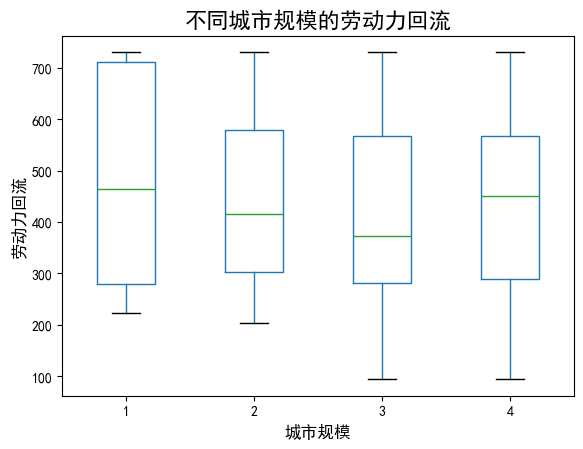

In [31]:
import matplotlib.pyplot as plt

# 绘制箱型图，根据citysize分组
merged_citysize2019.boxplot(column='back', by='citysize', grid=False)

# 设置matplotlib支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统

# 设置图表标题和轴标签
plt.suptitle('')
plt.title('不同城市规模的劳动力回流', fontsize = 16)
plt.xlabel('城市规模', fontsize = 12)
plt.ylabel('劳动力回流', fontsize = 12)

# 显示图表
plt.show()

In [20]:
merged_citysize = pd.merge(df_combined, citysize, on=['prov_CHN'], how='inner')

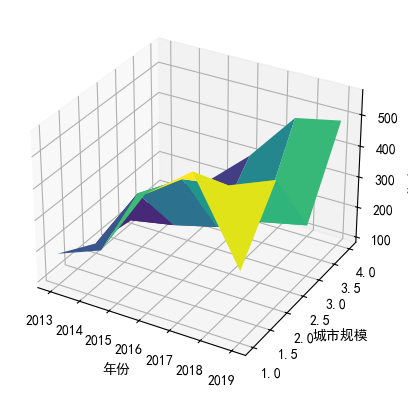

In [23]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata


# 创建网格点
grid_x, grid_y = np.mgrid[2013:2019:5j, 1:4:4j]

# 插值
grid_z = griddata((merged_citysize['year'], merged_citysize['citysize']), merged_citysize['back'], (grid_x, grid_y), method='cubic')

# 创建3D图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制3D曲面
ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')

# 设置标签
ax.set_xlabel('年份')
ax.set_ylabel('城市规模')
ax.set_zlabel('劳动力回流')


# 显示图形
plt.show()

In [21]:
print(master_2019)

              hhid  pline          hhcid  track  rural pa28 pab pabcd  \
0       2019000001      1  hhcid20170423      0      0                  
1       2019000002      4  hhcid20170423      0      0        A         
2       2019000002      3  hhcid20170423      0      0        A         
3       2019000002      2  hhcid20170423      0      0        A         
4       2019000002      1  hhcid20170423      0      0        A         
...            ...    ...            ...    ...    ...  ...  ..   ...   
107003  2019034642      4  hhcid20131048      0      0   15   B         
107004  2019034643      4  hhcid20131048      0      0        A    A1   
107005  2019034643      1  hhcid20131048      0      0        A    A1   
107006  2019034643      3  hhcid20131048      0      0        A    A1   
107007  2019034643      2  hhcid20131048      0      0        A    A1   

          weight_hh   weight_ind  ... agri_debt busi_debt house_debt  \
0        800.748047   616.559753  ...       NaN    